# example_CC

## 说明

- 功能：计算三台站互相关函数。
- 数据来源：`FJ-QED/ref/CC-FJpy-master/examples/ThreeStationsCCExample.zip`。
- 主要输出：频域互相关函数图、时域互相关函数剖面图。
- 关键函数：`ccfj.CC(...)`。


In [1]:
from pathlib import Path
import shutil
import sys
import tempfile
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from obspy import read

CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name == "examples" else CWD
REF_EXAMPLES = ROOT.parent / "ref" / "CC-FJpy-master" / "examples"
sys.path.insert(0, str(ROOT))

import ccfj


## 辅助函数

- `extract_zip(...)`：将参考示例压缩包解压到临时目录。
- `great_circle_km(...)`：根据经纬度计算台间大圆距离，单位 `km`。
- `common_day(...)`：寻找多个台站记录共有的日期。


In [2]:
def extract_zip(zip_path: Path) -> Path:
    tmp_root = Path(tempfile.mkdtemp(prefix="fjpy_win_cc_nb_"))
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(tmp_root)
    return tmp_root


def great_circle_km(p1, p2):
    lat1, lon1 = p1
    lat2, lon2 = p2
    r = 6371.0088
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    return float(2.0 * r * np.arcsin(np.sqrt(a)))


def common_day(station_dirs):
    day_sets = []
    for sta_dir in station_dirs:
        days = set()
        for sac in sta_dir.glob("*.SAC"):
            parts = sac.name.split("-")
            if len(parts) >= 4:
                days.add(parts[3])
        if days:
            day_sets.append(days)
    common = set.intersection(*day_sets) if day_sets else set()
    if not common:
        raise RuntimeError("未找到共同日期。")
    return sorted(common)[0]


## 主流程

- 输入波形：三台站 `BHZ` 分量 SAC 记录。
- 输入给 `ccfj.CC(...)` 的关键量：
  - `data`：按台站平铺的时域波形。
  - `startend`：每个台站有效数据段起止索引。
  - `pairs`：台站对索引。
- 输出 `ncfs`：形状为 `(nPairs, nf)` 的复数互相关频谱。


In [3]:
# 采用与原项目一致的 Crosscorrelation 数据流，但只保留当前 Win 版已验证可运行的主流程。
# 直接使用三台站示例计算互相关，不再混用原项目的按天汇总流程。
src = REF_EXAMPLES / "ThreeStationsCCExample.zip"
tmp_root = extract_zip(src)
data_root = tmp_root / "DataDemo"
station_file = tmp_root / "stations"
station_dirs = sorted([p for p in data_root.iterdir() if p.is_dir()])
day = common_day(station_dirs[:3])

coords = {}
for line in station_file.read_text(encoding="utf-8").splitlines():
    parts = line.split()
    if len(parts) >= 3:
        coords[parts[0]] = (float(parts[2]), float(parts[1]))

traces = []
stations = []
for sta_dir in station_dirs[:3]:
    files = sorted(sta_dir.glob(f"*{day}*BHZ.SAC"))
    if not files:
        continue
    tr = read(str(files[0]))[0]
    tr.detrend("demean")
    traces.append(tr)
    stations.append(sta_dir.name)

if len(traces) < 2:
    raise RuntimeError("至少需要两条记录。")

nsta = len(traces)
npts = min(tr.stats.npts for tr in traces)
Fs = float(traces[0].stats.sampling_rate)
fftlen = min(int(Fs * 3600), npts)
nf = min(512, fftlen // 2 + 1)
fstride = 1

data = np.zeros(nsta * npts, dtype=np.float32)
startend = np.zeros(nsta * 2, dtype=np.int32)
for i, tr in enumerate(traces):
    data[i * npts : (i + 1) * npts] = tr.data[:npts].astype(np.float32, copy=False)
    startend[i * 2] = 0
    startend[i * 2 + 1] = npts

pairs = ccfj.GetStationPairs(nsta)
pair_names = []
pair_dist_km = []
for ipair in range(len(pairs) // 2):
    a = int(pairs[2 * ipair])
    b = int(pairs[2 * ipair + 1])
    sta_a = stations[a]
    sta_b = stations[b]
    pair_names.append(f"{sta_a} - {sta_b}")
    pair_dist_km.append(great_circle_km(coords[sta_a], coords[sta_b]))
pair_dist_km = np.asarray(pair_dist_km, dtype=np.float32)
order = np.argsort(pair_dist_km)
ncfs = ccfj.CC(
    npts,
    nsta,
    nf,
    fftlen,
    pairs,
    startend,
    data,
    overlaprate=0.5,
    nThreads=4,
    fstride=fstride,
    ifonebit=0,
    ifspecwhittenning=1,
)
f = np.arange(nf, dtype=np.float32) * Fs / fftlen * fstride
ncfs_sorted = ncfs[order]
pair_dist_sorted = pair_dist_km[order]
pair_names_sorted = [pair_names[i] for i in order]
dt = 1.0 / f[-2] / 2.0
t = (np.linspace(-len(f) - 1, len(f) - 1, 2 * (len(f) - 1)) - 0.5) * dt
ncfst = np.real(np.fft.fftshift(np.fft.irfft(ncfs_sorted, axis=1), axes=1))

summary = {
    "stations": stations,
    "day": day,
    "shape": list(ncfs.shape),
    "abs_max": float(np.max(np.abs(ncfs))),
    "abs_mean": float(np.mean(np.abs(ncfs))),
    "pair_dist_km": [float(x) for x in pair_dist_sorted],
}
summary


{'stations': ['TA-P37A', 'TA-T38A', 'TA-U38A'],
 'day': '200',
 'shape': [3, 512],
 'abs_max': 0.957446813583374,
 'abs_mean': 0.179674431681633,
 'pair_dist_km': [66.7850570678711, 283.9009704589844, 350.145751953125]}

## 绘图说明

- 左图：`Cross-correlation functions in frequency domain`。
- 右图：`Cross-correlation functions in time domain`。
- 时域图横轴为延时 `Lag time (s)`，纵轴为台间距 `Interstation distance (km)`。


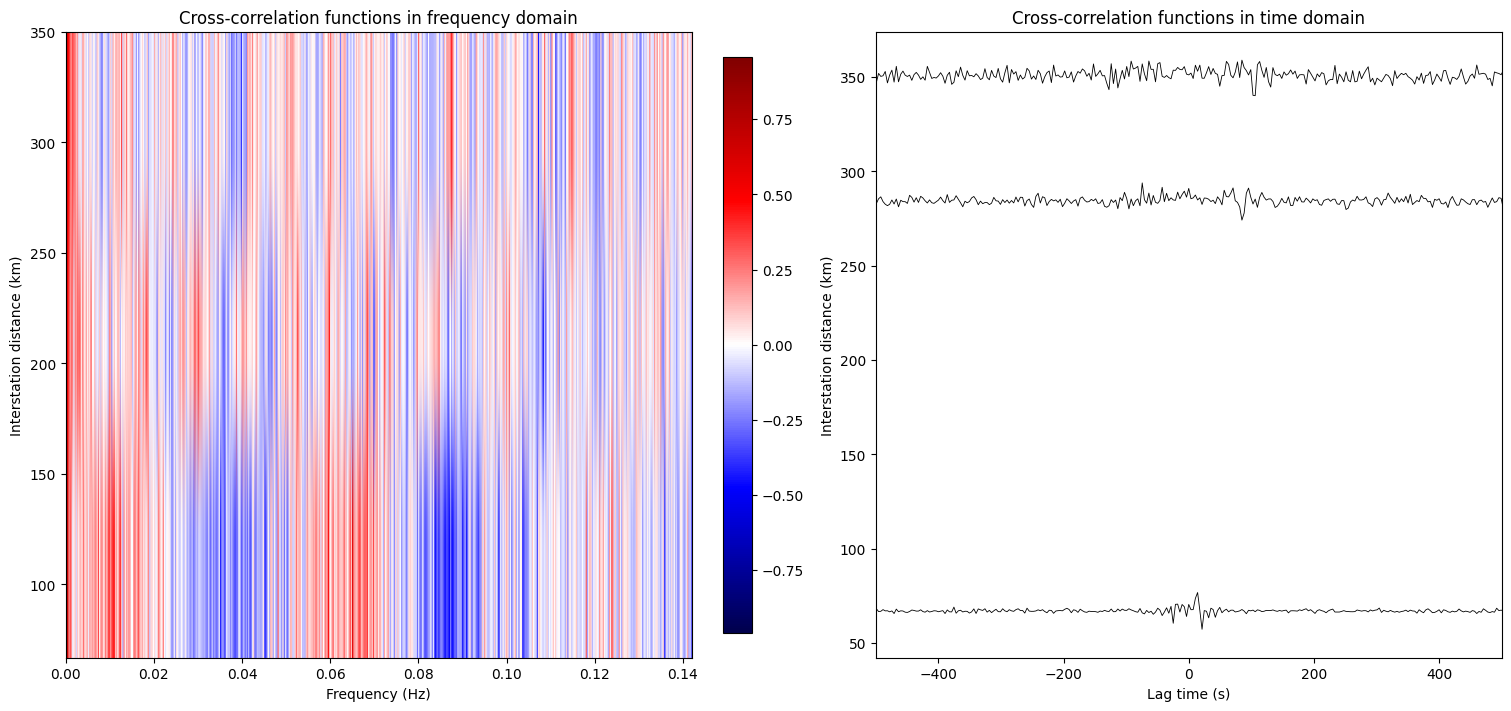

In [4]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 7), constrained_layout=True)
vmax = float(np.max(np.abs(np.real(ncfs_sorted))))
if vmax <= 0:
    vmax = 1.0
im = ax[0].imshow(np.flip(np.real(ncfs_sorted), 0), extent=[float(np.min(f)), float(np.max(f)), float(np.min(pair_dist_sorted)), float(np.max(pair_dist_sorted))], aspect="auto", cmap="seismic", vmin=-vmax, vmax=vmax)
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Interstation distance (km)")
ax[0].set_title("Cross-correlation functions in frequency domain")
fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)

# 时域输出采用原项目常见的剖面展示方式：横轴为延时，纵轴为台间距。
for i in range(len(pair_dist_sorted)):
    curve = ncfst[i, :]
    scale = float(np.max(np.abs(curve)))
    if scale > 0:
        ax[1].plot(t, curve / scale * 10.0 + pair_dist_sorted[i], "k", linewidth=0.6)
ax[1].set_xlim([-500, 500])
ax[1].set_xlabel("Lag time (s)")
ax[1].set_ylabel("Interstation distance (km)")
ax[1].set_title("Cross-correlation functions in time domain")
plt.show()


In [5]:
shutil.rmtree(tmp_root, ignore_errors=True)
print("中文自检：互相关 notebook 已按 UTF-8 写入。")


中文自检：互相关 notebook 已按 UTF-8 写入。


## 频散曲线拾取、分模与地下速度结构反演

### 方法说明

这一部分不再使用“单条基阶脊线动态规划”的简化拾取，而是改为参考 `DisperNet` 开源仓库中公开的分模后处理思路，
采用“候选点提取 + 分模 + 插值/平滑 + 约束跟踪”的本地化流程。由于仓库公开代码中的 `pick(...)`
依赖远程服务端模型，而该模型和在线接口并不在当前仓库内，因此这里保留 `DisperNet` 已公开的核心思想：

1. 在频散能量图中按频率列提取多个局部峰值候选点。
2. 使用与 `DisperNet.modeSeparation(...)` 一致的层次聚类思想，对候选点做基阶/高阶分模。
3. 使用与 `DisperNet.curveInterp(...)`、`curveSmooth(...)` 一致的插值和平滑思想，获得连续的模式曲线。
4. 在每个模式的候选速度带内再次执行连续跟踪，减少跳模和离散点造成的误拾取。

### 反演目标函数

将拾取到的观测频散点记为 $(f_i, c_i^{obs}, m_i)$，反演模型中的主要未知量为各层的 $V_s$。
`QEDispInv-win` 中采用的目标函数可以写为：

$$
\Phi(\mathbf{V_s})=
\sum_i w_{m_i}\left[c_i^{syn}(\mathbf{V_s})-c_i^{obs}\right]^2
+ \lambda \left\|L\left(\mathbf{V_s}-\mathbf{V_s}^{ref}\right)\right\|_2^2
$$

其中：

- 第一项是观测频散与理论频散之间的失配；
- $w_{m_i}$ 是不同模式的权重；
- 第二项是正则化项，用于抑制不合理的速度振荡；
- $L$ 为差分平滑矩阵；
- $\mathbf{V_s}^{ref}$ 为参考模型中的初始剪切波速度。

### 结果统计量说明

速度结构图中的几条统计曲线含义如下：

- `Median Vs`：在每个深度采样点上，对所有有效反演模型的 $V_s$ 做逐点中位数统计。它反映“最具代表性”的速度剖面，
  相比简单平均值更不容易受到少量异常模型的影响。
- `P10` / `P90`：分别表示速度后验样本在该深度处的第 10 百分位和第 90 百分位。
  它们围成的带宽可以理解为一个稳健的不确定性范围：带宽越窄，表示该深度处反演约束越强；带宽越宽，表示该深度处不确定性越大。
- `Initial Vs`：参考模型插值到统计深度网格后的初始速度曲线，用于对比反演前后的更新幅度。

### 反演参数解释与调节原则

这里把所有反演参数直接写在 notebook 内，便于复现实验。常用参数意义如下：

- `vs_width`：每层 $V_s$ 搜索区间总宽度。过小会限制模型更新，过大则容易引入非唯一性。
- `lambda_`：正则化系数。值越大，模型越平滑；值越小，越容易贴合数据但也更容易出现不稳定振荡。
- `reg_type`：正则化类型。`2` 表示自适应平滑，通常适合频散反演。
- `num_init`：多初值反演次数。正规反演中不宜只使用单初值。
- `num_noise`：对观测频散执行扰动重采样的次数，用于评估不确定性。
- `rand_vs` / `rand_depth`：是否对初始速度或分层深度进行随机化。
- `weight`：不同模式的失配权重。通常基阶权重大于高阶，因为基阶连续性最好、稳定性最高。
- `sigma`：各模式的观测不确定度，用于噪声扰动重采样。
- `maxiter`：单次 L-BFGS-B 迭代上限。正规反演应明显高于演示级设置。
- `zmax`：统计与反演的最大深度，应与可解析的最大波长相匹配。

### 本轮改动重点

1. 频散拾取改为 `DisperNet` 风格的候选点分模流程，并尝试同时保留基阶和高阶。
2. `example_EQ.ipynb` 不再直接对三窗平均图做单条基阶拾取，而是采用更稳定的模式分离与更正规的反演参数。
3. 三个 notebook 的末尾都统一输出：
   - 速度结构图；
   - 观测频散图；
   - 观测频散与反演模型正演理论频散对比图。


In [6]:
from pathlib import Path
import sys

import numpy as np
from scipy.cluster.vq import whiten
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from sklearn.cluster import AgglomerativeClustering

QED_ROOT = ROOT.parent / "QEDispInv-win"
if str(QED_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(QED_ROOT / "src"))

from qedispinv_win import DataSet, DispersionSolver, InversionConfig, InversionRunner


def extract_dispersion_candidates(
    image,
    freq,
    vel_km_s,
    fmin,
    fmax,
    threshold,
    prominence,
    distance,
    max_peaks_per_freq,
    freq_step,
):
    """Extract local spectral peaks column by column as DisperNet-style candidates."""
    image = np.asarray(image, dtype=np.float64)
    freq = np.asarray(freq, dtype=np.float64)
    vel_km_s = np.asarray(vel_km_s, dtype=np.float64)

    freq_idx = np.where((freq >= fmin) & (freq <= fmax))[0]
    freq_idx = freq_idx[:: max(int(freq_step), 1)]
    points = []
    for j in freq_idx:
        column = np.asarray(image[:, j], dtype=np.float64)
        column = np.nan_to_num(column, nan=0.0, posinf=0.0, neginf=0.0)
        col_max = float(np.max(column))
        if col_max <= 0.0:
            continue
        column /= col_max
        peaks, props = find_peaks(
            column,
            height=float(threshold),
            prominence=float(prominence),
            distance=max(int(distance), 1),
        )
        if peaks.size == 0:
            continue
        order = np.argsort(props["peak_heights"])[::-1][: max(int(max_peaks_per_freq), 1)]
        for k in order:
            peak = int(peaks[k])
            points.append([freq[j], vel_km_s[peak], float(column[peak])])

    if not points:
        raise RuntimeError("候选点提取失败：请检查频带、阈值和频散图能量分布。")
    return np.asarray(points, dtype=np.float64)


def dispernet_mode_separation(points, modes):
    """Reproduce the mode-separation idea公开在 DisperNet 仓库中的层次聚类分模。"""
    modes = int(modes)
    if modes < 1:
        raise ValueError("modes 必须大于等于 1。")
    curve_whiten = whiten(points[:, :2])
    labels = AgglomerativeClustering(
        n_clusters=modes,
        linkage="single",
        compute_full_tree=True,
    ).fit_predict(curve_whiten)

    mean_velocity = np.asarray([np.mean(points[labels == mode, 1]) for mode in range(modes)], dtype=np.float64)
    mode_order = np.argsort(mean_velocity)
    labels_sorted = np.zeros_like(labels)
    for new_mode, old_mode in enumerate(mode_order):
        labels_sorted[labels == old_mode] = new_mode

    out = np.column_stack([points, labels_sorted])
    rows = []
    for mode in range(modes):
        sub = out[out[:, -1] == mode]
        sub = sub[np.argsort(sub[:, 0])]
        rows.append(sub)
    return np.vstack(rows)


def dispernet_auto_mode_separation(points, max_modes=5, min_points=8):
    """Use the same逐步增模 heuristic as DisperNet.autoSeparation(...)."""
    fmax = float(np.max(points[:, 0]))
    fmin = float(np.min(points[:, 0]))
    cmax = float(np.max(points[:, 1]))
    cmin = float(np.min(points[:, 1]))
    f_search_start = 0.05 * (fmax - fmin) + fmin
    c_jump_limit = 0.10 * (cmax - cmin)

    best = dispernet_mode_separation(points, 1)
    for mode_count in range(1, int(max_modes) + 1):
        candidate = dispernet_mode_separation(points, mode_count)
        valid = True
        for mode in range(mode_count):
            sub = candidate[candidate[:, -1] == mode]
            sub = sub[sub[:, 0] > f_search_start]
            sub = sub[np.argsort(sub[:, 0])]
            if sub.shape[0] < max(int(min_points), 3):
                valid = False
                break
            if np.std(np.diff(sub[:, 1])) > c_jump_limit:
                valid = False
                break
        if valid:
            best = candidate
        else:
            break
    return best


def filter_clustered_modes(curves, min_points=6, min_frequency_span=0.01):
    """Remove tiny or too-short mode branches before refinement."""
    curves = np.asarray(curves, dtype=np.float64)
    kept = []
    for mode in sorted({int(x) for x in curves[:, -1]}):
        sub = curves[curves[:, -1] == mode]
        if sub.shape[0] < int(min_points):
            continue
        if float(np.max(sub[:, 0]) - np.min(sub[:, 0])) < float(min_frequency_span):
            continue
        kept.append(sub)
    if not kept:
        raise RuntimeError("分模后没有模式通过 QC。")
    return np.vstack(kept)


def reindex_modes(curves):
    """Renumber surviving mode labels to 0, 1, 2, ... after QC or interpolation."""
    curves = np.asarray(curves, dtype=np.float64)
    out = curves.copy()
    unique_modes = sorted({int(x) for x in out[:, -1]})
    for new_mode, old_mode in enumerate(unique_modes):
        out[out[:, -1] == old_mode, -1] = new_mode
    return out


def refine_modes_with_guided_tracking(
    image,
    freq,
    vel_km_s,
    clustered_curves,
    continuity=80.0,
    prior_weight=35.0,
    band_padding=0.20,
    smooth_sigma=1.0,
    mode_frequency_caps=None,
):
    """Refine every separated mode inside its own velocity band using continuous tracking."""
    image = np.asarray(image, dtype=np.float64)
    freq = np.asarray(freq, dtype=np.float64)
    vel_km_s = np.asarray(vel_km_s, dtype=np.float64)
    mode_frequency_caps = {} if mode_frequency_caps is None else dict(mode_frequency_caps)

    curves = []
    for mode in sorted({int(x) for x in clustered_curves[:, -1]}):
        sub = clustered_curves[clustered_curves[:, -1] == mode]
        sub = sub[np.argsort(sub[:, 0])]
        if mode in mode_frequency_caps:
            sub = sub[sub[:, 0] <= float(mode_frequency_caps[mode])]
        if sub.shape[0] < 4:
            continue

        fmin = float(np.min(sub[:, 0]))
        fmax = float(np.max(sub[:, 0]))
        vmin = max(float(np.min(sub[:, 1]) - band_padding), float(np.min(vel_km_s)))
        vmax = min(float(np.max(sub[:, 1]) + band_padding), float(np.max(vel_km_s)))

        freq_idx = np.where((freq >= fmin) & (freq <= fmax))[0]
        vel_idx = np.where((vel_km_s >= vmin) & (vel_km_s <= vmax))[0]
        if freq_idx.size < 2 or vel_idx.size < 2:
            continue

        local_freq = freq[freq_idx]
        local_vel = vel_km_s[vel_idx]
        local_img = np.asarray(image[np.ix_(vel_idx, freq_idx)], dtype=np.float64)
        local_img /= np.maximum(local_img.max(axis=0, keepdims=True), 1.0e-12)
        energy = np.log(np.maximum(local_img, 1.0e-6))

        prior_curve = np.interp(local_freq, sub[:, 0], sub[:, 1], left=sub[0, 1], right=sub[-1, 1])
        score = energy[:, 0] - 50.0 * (local_vel - prior_curve[0]) ** 2
        back = np.zeros((energy.shape[0], energy.shape[1]), dtype=np.int32)
        for j in range(1, energy.shape[1]):
            transition = (
                score[:, None]
                - float(continuity) * (local_vel[:, None] - local_vel[None, :]) ** 2
                - float(prior_weight) * (local_vel[None, :] - prior_curve[j]) ** 2
            )
            best_prev = np.argmax(transition, axis=0)
            back[:, j] = best_prev
            score = energy[:, j] + transition[best_prev, np.arange(energy.shape[0])]

        ridge = np.zeros(energy.shape[1], dtype=np.int32)
        ridge[-1] = int(np.argmax(score))
        for j in range(energy.shape[1] - 1, 0, -1):
            ridge[j - 1] = back[ridge[j], j]

        velocity_curve = gaussian_filter1d(local_vel[ridge], float(smooth_sigma))
        curves.append(np.column_stack([local_freq, velocity_curve, np.full(local_freq.shape, mode, dtype=np.float64)]))

    if not curves:
        raise RuntimeError("模式 refinement 失败。")
    return np.vstack(curves)


def dispernet_interp_and_smooth(curves, freq_sampling, smooth_sigma=1.0):
    """Interpolate every mode to a regular frequency series and smooth it."""
    curves = np.asarray(curves, dtype=np.float64)
    freq_sampling = np.asarray(freq_sampling, dtype=np.float64)
    output = []
    for mode in sorted({int(x) for x in curves[:, 2]}):
        sub = curves[curves[:, 2] == mode]
        sub = sub[np.argsort(sub[:, 0])]
        if sub.shape[0] < 2:
            continue
        fpart = freq_sampling[(freq_sampling >= np.min(sub[:, 0])) & (freq_sampling <= np.max(sub[:, 0]))]
        if fpart.size < 2:
            continue
        velocity_interp = np.interp(fpart, sub[:, 0], sub[:, 1])
        velocity_interp = gaussian_filter1d(velocity_interp, float(smooth_sigma))
        output.append(np.column_stack([fpart, velocity_interp, np.full(fpart.shape, mode, dtype=np.float64)]))
    if not output:
        raise RuntimeError("插值和平滑后没有有效模式。")
    return reindex_modes(np.vstack(output))


def build_reference_model(depth_nodes_km, vs_profile_km_s, rho0, rho_span, vp_vs):
    """Build the reference layered model directly inside the notebook."""
    z = np.asarray(depth_nodes_km, dtype=np.float64)
    vs = np.asarray(vs_profile_km_s, dtype=np.float64)
    if z.size != vs.size:
        raise ValueError("depth_nodes_km 和 vs_profile_km_s 的长度必须一致。")
    rho = rho0 + rho_span * (vs - np.min(vs)) / max(np.ptp(vs), 1.0e-6)
    vp = np.maximum(vs * float(vp_vs), vs + 0.4)
    return np.column_stack([np.arange(1, z.size + 1), z, rho, vs, vp])


def run_dispersion_inversion_workflow(
    image,
    freq,
    vel_km_s,
    picker_config,
    model_config,
    inversion_config,
    seed=20260605,
):
    """Run candidate extraction, mode separation, refinement, inversion, and forward prediction."""
    candidates = extract_dispersion_candidates(image=image, freq=freq, vel_km_s=vel_km_s, **picker_config["candidate"])
    if "cluster_modes" in picker_config and picker_config["cluster_modes"] is not None:
        clustered = dispernet_mode_separation(candidates, picker_config["cluster_modes"])
    else:
        clustered = dispernet_auto_mode_separation(candidates, max_modes=picker_config.get("max_modes", 5))
    clustered = reindex_modes(filter_clustered_modes(
        clustered,
        min_points=picker_config.get("min_points", 6),
        min_frequency_span=picker_config.get("min_frequency_span", 0.01),
    ))
    refined = refine_modes_with_guided_tracking(
        image=image,
        freq=freq,
        vel_km_s=vel_km_s,
        clustered_curves=clustered,
        continuity=picker_config.get("continuity", 80.0),
        prior_weight=picker_config.get("prior_weight", 35.0),
        band_padding=picker_config.get("band_padding", 0.20),
        smooth_sigma=picker_config.get("refine_smooth_sigma", 1.0),
        mode_frequency_caps=picker_config.get("mode_frequency_caps"),
    )
    observed_dispersion = dispernet_interp_and_smooth(
        refined,
        freq_sampling=np.asarray(picker_config["freq_sampling"], dtype=np.float64),
        smooth_sigma=picker_config.get("interp_smooth_sigma", 1.0),
    )

    model_ref = build_reference_model(**model_config)
    dataset = DataSet(observed_dispersion)
    config = InversionConfig(**inversion_config)
    result = InversionRunner(model_ref, dataset, config, sh=False, seed=seed).run()
    forward_dispersion = forward_on_observed_modes(result["model_mean"], observed_dispersion)
    observed_dispersion, forward_dispersion = filter_valid_forward_pairs(observed_dispersion, forward_dispersion)
    return candidates, clustered, observed_dispersion, model_ref, result, forward_dispersion


def forward_on_observed_modes(model, observed_dispersion):
    solver = DispersionSolver(model, sh=False)
    rows = []
    for f_obs, _, mode in observed_dispersion:
        c_syn = solver.search_mode(float(f_obs), int(mode))
        rows.append([float(f_obs), float(c_syn), int(mode)])
    return np.asarray(rows, dtype=np.float64)


def filter_valid_forward_pairs(observed_dispersion, forward_dispersion):
    """Drop rows whose synthetic phase velocity is NaN, then renumber surviving modes."""
    observed_dispersion = np.asarray(observed_dispersion, dtype=np.float64)
    forward_dispersion = np.asarray(forward_dispersion, dtype=np.float64)
    keep = np.isfinite(forward_dispersion[:, 1])
    if not np.any(keep):
        raise RuntimeError("No finite synthetic phase velocities were found for the picked dispersion points.")
    return reindex_modes(observed_dispersion[keep]), reindex_modes(forward_dispersion[keep])


def summarize_inversion(observed_dispersion, forward_dispersion, result):
    abs_misfit = np.abs(observed_dispersion[:, 1] - forward_dispersion[:, 1])
    finite = np.isfinite(abs_misfit)
    summary = {
        "picked_points": int(observed_dispersion.shape[0]),
        "mode_counts": {int(mode): int(np.sum(observed_dispersion[:, 2] == mode)) for mode in np.unique(observed_dispersion[:, 2]).astype(int)},
        "fitness_min": float(np.min(result["fitness"])),
        "fitness_mean": float(np.mean(result["fitness"])),
        "mean_abs_phase_velocity_misfit_km_s": float(np.mean(abs_misfit[finite])) if np.any(finite) else float("nan"),
        "median_abs_phase_velocity_misfit_km_s": float(np.median(abs_misfit[finite])) if np.any(finite) else float("nan"),
        "num_valid_models": int(result["num_valid"][0]),
        "depth_max_km": float(result["model_mean"][-1, 1]),
    }
    return summary


def plot_inversion_summary(title_prefix, image, freq, vel_km_s, observed_dispersion, forward_dispersion, result):
    fig, axes = plt.subplots(ncols=3, figsize=(18, 6), constrained_layout=True)

    hist = np.ma.masked_less_equal(result["vs_hist2d"], 0.0)
    z_sample = result["z_sample"]
    vs_sample = result["vs_sample"]
    dv = vs_sample[1] - vs_sample[0]
    dz = z_sample[1] - z_sample[0]

    axes[0].pcolormesh(vs_sample - dv / 2.0, z_sample - dz / 2.0, hist, cmap="Wistia", shading="auto")
    axes[0].plot(result["vs_ref"], z_sample, "k-", lw=1.4, alpha=0.65, label="Initial Vs")
    axes[0].plot(result["vs_median"], z_sample, "-", color="tab:blue", lw=2.0, label="Median Vs")
    axes[0].plot(result["vs_cred10"], z_sample, "--", color="tab:blue", lw=1.0, alpha=0.85, label="P10 / P90")
    axes[0].plot(result["vs_cred90"], z_sample, "--", color="tab:blue", lw=1.0, alpha=0.85)
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Vs (km/s)")
    axes[0].set_ylabel("Depth (km)")
    axes[0].set_title(f"{title_prefix}Velocity Model")
    axes[0].legend(loc="lower right")
    axes[0].grid(linestyle=":", alpha=0.4)

    im = axes[1].pcolormesh(freq, vel_km_s, image, cmap="jet", shading="auto", vmin=0.0, vmax=0.9)
    color_cycle = ["w", "cyan", "magenta", "yellow", "lime"]
    for mode in sorted({int(x) for x in observed_dispersion[:, 2]}):
        sub = observed_dispersion[observed_dispersion[:, 2] == mode]
        axes[1].plot(sub[:, 0], sub[:, 1], ".-", color=color_cycle[mode % len(color_cycle)], lw=1.2, ms=5, label=f"Mode {mode}")
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("Phase velocity (km/s)")
    axes[1].set_title(f"{title_prefix}Observed Dispersion Image")
    axes[1].legend(loc="upper right")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    for mode in sorted({int(x) for x in observed_dispersion[:, 2]}):
        sub_obs = observed_dispersion[observed_dispersion[:, 2] == mode]
        sub_syn = forward_dispersion[forward_dispersion[:, 2] == mode]
        color = f"C{mode % 10}"
        axes[2].plot(sub_obs[:, 0], sub_obs[:, 1], "o", ms=4, color=color, label=f"Observed mode {mode}")
        axes[2].plot(sub_syn[:, 0], sub_syn[:, 1], "-", lw=1.8, color=color, alpha=0.9, label=f"Synthetic mode {mode}")
    axes[2].set_xlabel("Frequency (Hz)")
    axes[2].set_ylabel("Phase velocity (km/s)")
    axes[2].set_title(f"{title_prefix}Observed vs Synthetic Dispersion")
    axes[2].grid(linestyle=":", alpha=0.4)
    axes[2].legend(loc="best", fontsize=8)
    plt.show()


### example_CC 的观测频散构造与参数设定

`example_CC` 前半部分得到的是三台站互相关频谱 `ncfs_sorted`。这里先调用 `ccfj.fj_noise(...)`
把互相关结果映射到 $f$-$c$ 平面，再用 `DisperNet` 风格的候选点提取和分模流程自动识别频散支。

本例只有 3 对台站、频散分辨率有限，因此高阶模式的稳定性弱于 `noise` 与 `EQ` 两个例子。
这里仍然尝试自动分模，但最终通过 QC 的模式数取决于实际能量图质量。


In [7]:
cc_dispersion_c_mps = np.linspace(1500.0, 5000.0, 260, dtype=np.float32)
cc_dispersion_image = ccfj.fj_noise(
    np.real(ncfs_sorted),
    pair_dist_sorted * 1e3,
    cc_dispersion_c_mps,
    f,
    fstride=1,
    itype=1,
    func=0,
)

cc_picker_config = {
    "candidate": {
        "fmin": 0.08,
        "fmax": 0.145,
        "threshold": 0.25,
        "prominence": 0.015,
        "distance": 4,
        "max_peaks_per_freq": 5,
        "freq_step": 1,
    },
    "cluster_modes": 1,
    "min_points": 5,
    "min_frequency_span": 0.004,
    "continuity": 65.0,
    "prior_weight": 30.0,
    "band_padding": 0.18,
    "refine_smooth_sigma": 1.0,
    "interp_smooth_sigma": 1.0,
    "freq_sampling": np.unique(np.round(f[(f >= 0.08) & (f <= 0.145)], 6)),
}

cc_model_config = {
    "depth_nodes_km": [0.0, 0.3, 0.7, 1.2, 2.0, 3.2, 4.8, 6.8, 9.3, 12.5, 16.5, 21.0],
    "vs_profile_km_s": [1.90, 2.05, 2.20, 2.40, 2.65, 2.95, 3.20, 3.45, 3.70, 3.95, 4.20, 4.40],
    "rho0": 1.95,
    "rho_span": 0.22,
    "vp_vs": 1.78,
}

cc_inversion_config = {
    "vs2model": "FixVpRho",
    "vs_width": 0.35,
    "lambda_": 6.0e-3,
    "reg_type": 2,
    "num_init": 8,
    "num_noise": 2,
    "rand_depth": False,
    "rand_vs": True,
    "zmax": 25.0,
    "r0": 0.5,
    "rmin": 1.0,
    "rmax": 1.3,
    "weight": [8.0],
    "maxiter": 24,
    "sigma": [0.05],
}

cc_candidates, cc_clustered, cc_observed_dispersion, cc_model_ref, cc_inv_result, cc_forward_dispersion = run_dispersion_inversion_workflow(
    image=cc_dispersion_image,
    freq=f,
    vel_km_s=cc_dispersion_c_mps / 1e3,
    picker_config=cc_picker_config,
    model_config=cc_model_config,
    inversion_config=cc_inversion_config,
)
cc_inversion_summary = summarize_inversion(cc_observed_dispersion, cc_forward_dispersion, cc_inv_result)
cc_inversion_summary


{'picked_points': 223,
 'mode_counts': {0: 223},
 'fitness_min': 1.8543648232764731,
 'fitness_mean': 1.8580953749383298,
 'mean_abs_phase_velocity_misfit_km_s': 0.37338823177234565,
 'median_abs_phase_velocity_misfit_km_s': 0.283869912269509,
 'num_valid_models': 16,
 'depth_max_km': 25.0}

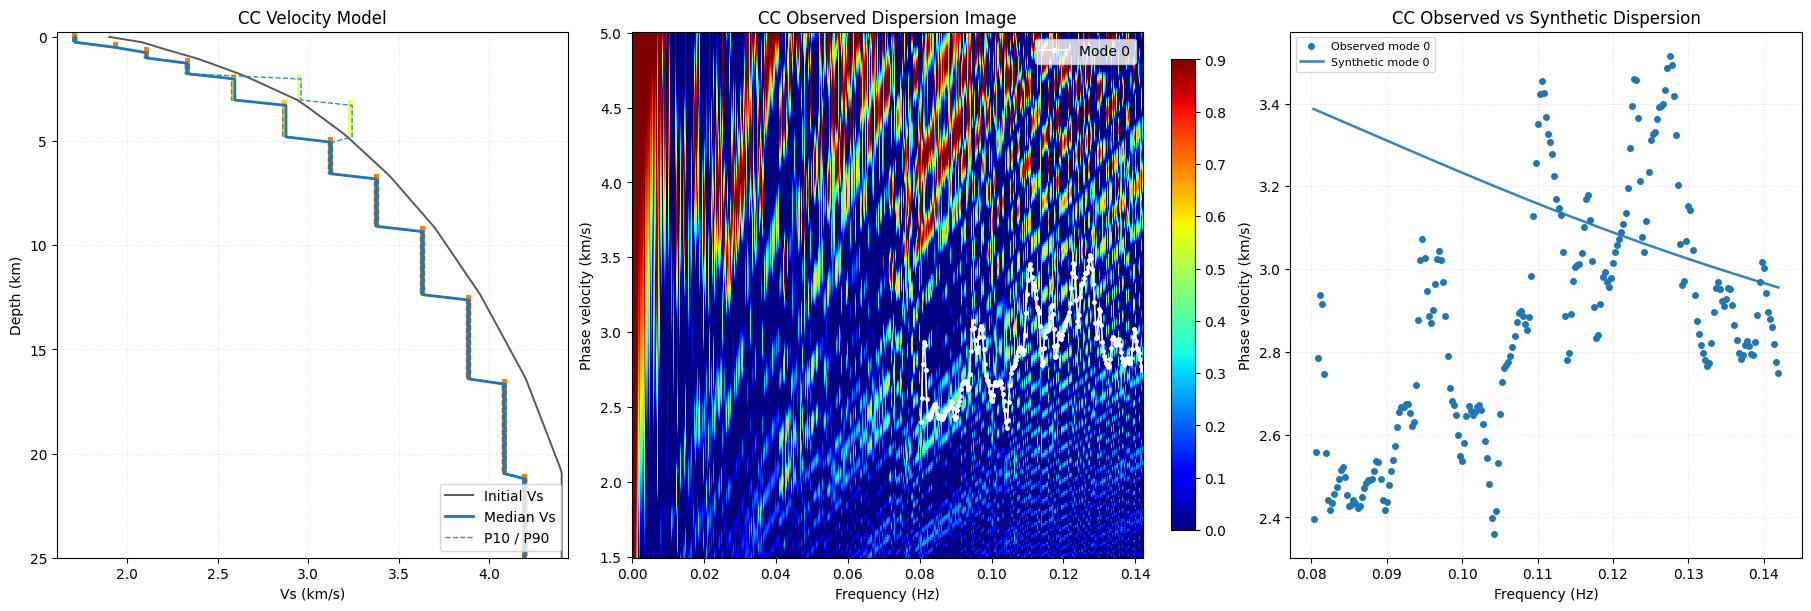

In [8]:
plot_inversion_summary(
    title_prefix="CC ",
    image=cc_dispersion_image,
    freq=f,
    vel_km_s=cc_dispersion_c_mps / 1e3,
    observed_dispersion=cc_observed_dispersion,
    forward_dispersion=cc_forward_dispersion,
    result=cc_inv_result,
)


In [9]:
print("中文自检：CC notebook 的追加反演区块已按 UTF-8 写入，且未出现乱码占位符。")


中文自检：CC notebook 的追加反演区块已按 UTF-8 写入，且未出现乱码占位符。
